### Program 2

1. imports

In [40]:
import numpy
import keras
from math import sqrt
from keras import layers, Input, Model, optimizers
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
import numpy as np

plt.style.use('dark_background')

1.2 auxiliary methods

In [47]:
def prepare_predictions(y_predictions):
    predictions = np.asarray(y_predictions).reshape(-1)
    if predictions.dtype.kind == "f":
        predictions = (predictions >= 0.5).astype("int32")
    return predictions


def get_accuracy(y_test, y_predictions) -> float :
    y_test = np.asarray(y_test).reshape(-1)
    y_predictions = prepare_predictions(y_predictions)
    assert len(y_test) == len(y_predictions)
    correct: int = 0

    for t, p in zip (y_test, y_predictions):
        if t == p:
            correct += 1

    return correct / len(y_test)


def sub_plot_decision_boundary(model, X_test, y_test, ax):
    x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
    y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 150),
        np.linspace(y_min, y_max, 150)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    Z = prepare_predictions(model.predict(grid_points, verbose=0))

    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)

def plot_performance_evaluation(ax, model_name, X_test, y_test, y_predictions):
    y_predictions = prepare_predictions(y_predictions)
    accuracy: str = str(get_accuracy(y_test, y_predictions) * 100) + "%"

    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_predictions, marker="o",s=50)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker=".")
    plt.title(str(model_name) + " | accuracy : " + accuracy)

    legend_elements = [
          Line2D([0], [0], marker='o', color='w', label='Predicted label', markersize=8),
          Line2D([0], [0], marker='.', color='w', label='True label', markersize=8),
    ]
    ax.legend(handles=legend_elements, title="Classification outcomes", loc='lower right')

2. generate a dataset

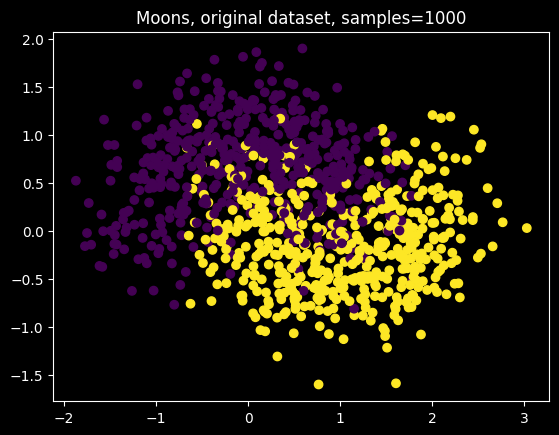

In [17]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1_000, noise=0.4)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Moons, original dataset, samples=" + str(len(X[:, 0])))
plt.show()

3. split data into test and training sets

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

4. plot test set, train set and original data

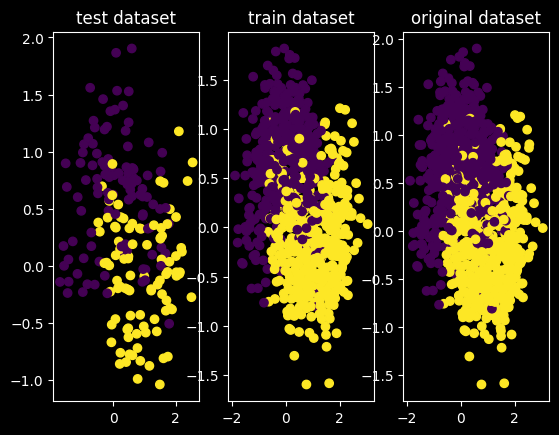

<Figure size 640x480 with 0 Axes>

In [50]:
_, (test_plot, train_plot, org_plot) = plt.subplots(1,3)

test_plot.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
test_plot.set_title("test dataset")
train_plot.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
train_plot.set_title("train dataset")
org_plot.scatter(X[:, 0], X[:, 1], c=y)
org_plot.set_title("original dataset")

plt.show()
plt.savefig("output/input_data.png")

5. define model

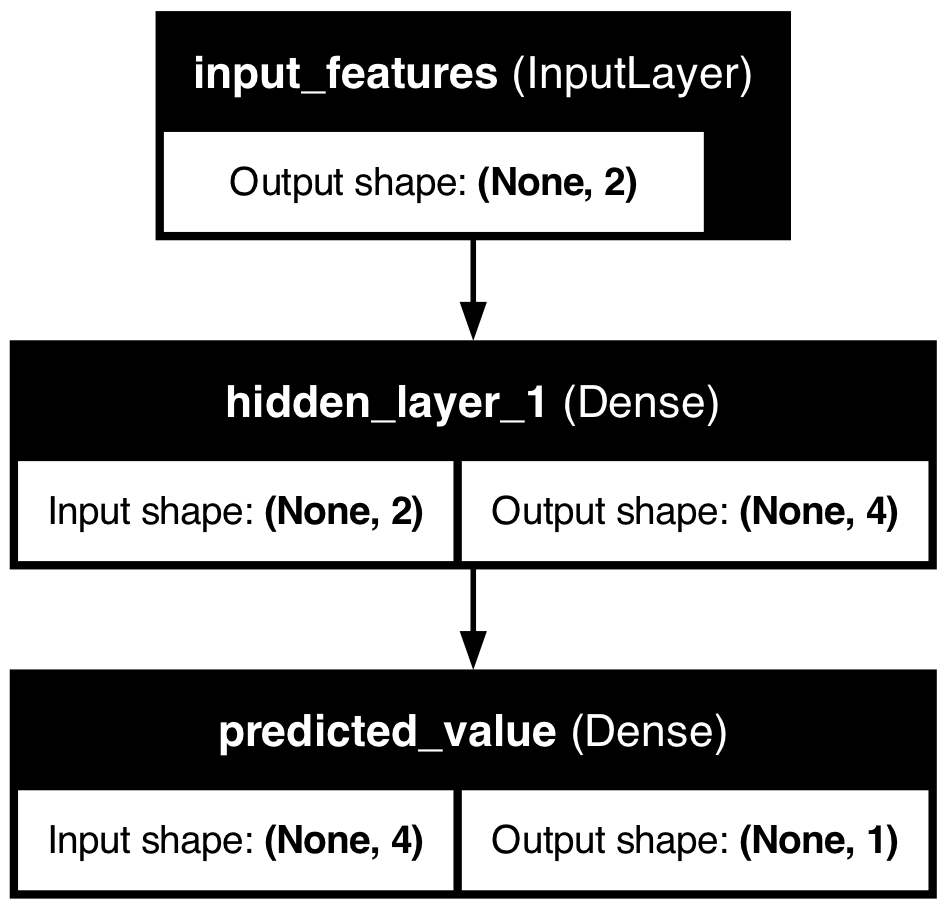

In [51]:
inputs = Input(shape=(2,), name="input_features")
x = layers.Dense(4, activation="relu", name="hidden_layer_1")(inputs)
outputs = layers.Dense(1, activation="sigmoid", name="predicted_value")(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="one_layer_binary_classifier"
)

keras.utils.plot_model(
    model,
    "output/two_layered_network_model.png",
    show_shapes=True,
    show_layer_names=True
)

6. compile model

In [52]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

7. train model

In [60]:
batch_size = int(sqrt(len(X_train)))

training_history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=batch_size,
    validation_split=0.2
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8438 - loss: 0.3572 - val_accuracy: 0.8375 - val_loss: 0.3465
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8422 - loss: 0.3569 - val_accuracy: 0.8313 - val_loss: 0.3483
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8438 - loss: 0.3581 - val_accuracy: 0.8375 - val_loss: 0.3496
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8453 - loss: 0.3581 - val_accuracy: 0.8250 - val_loss: 0.3492
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8406 - loss: 0.3579 - val_accuracy: 0.8375 - val_loss: 0.3507
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8422 - loss: 0.3568 - val_accuracy: 0.8250 - val_loss: 0.3468
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8422 - loss: 0.3574 - val_accuracy: 0.8375 - val_loss: 0.3465
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8406 - loss: 0.3570 - val_accuracy: 0.8375 - val_loss:

8. evaluate model

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


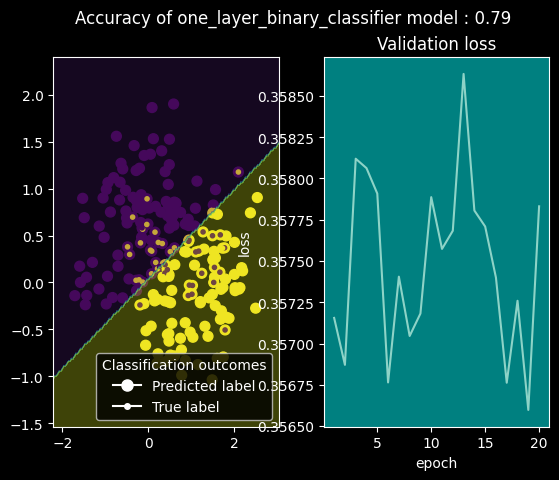

In [61]:
predictions_as_probabilities = model.predict(X_test)
# predicted_labels = (predictions_as_probabilities >= 0.5).astype("int32")

predictions = prepare_predictions(predictions_as_probabilities)
get_accuracy(y_test, predictions)

fig, (comparison, validation_loss) = plt.subplots(1,2)
plt.gca().set_facecolor('teal')

plot_performance_evaluation(comparison,
                            model_name="one_layer_binary_classifier",
                            X_test=X_test,
                            y_test=y_test,
                            y_predictions=predictions)

sub_plot_decision_boundary(model=model, X_test=X_test, y_test=y_test, ax=comparison)

validation_loss_values = training_history.history["loss"]
validation_loss.plot(range(1, len(validation_loss_values) + 1), validation_loss_values)
validation_loss.set_xlabel("epoch")
validation_loss.set_ylabel("loss")
validation_loss.set_title("Validation loss")

accuracy = get_accuracy(y_test=y_test, y_predictions=predictions)
fig.suptitle(f"Accuracy of one_layer_binary_classifier model : {accuracy}")

print(f"For the regression problem a network with single hidden layer has been chosen. "
      "The layer has 6 neurons and a RELU activation function to prevent the linearity problem. "
      "In the training the ADAM function was used for recalculation of neurons weights. The training "
      "consisted of 80 epochs which is a local optimum, as a decline in accuracy over 100 epochs was observed. Additionally the batch size was set as one-forth of the train dataset size.\n"
      ""
      "Configuration has yielded following results:\n"
      f"- The mean absolute error of training test is {mean_absolute_error}\n"
      f"- The validation loss decreased from {initial_loss} observed after first epoch to {final_loss} observed after {number_of_epochs}th epoch.")

plt.show()